# 11 分级仓位条件组合消融

上一阶段已经决定删除反弹强度条件。

本阶段研究：

1. 近期离场条件是否仍有独立价值；
2. 快均线斜率条件是否仍有独立价值；
3. 两个条件是否存在交互；
4. 是否可以进一步简化为基础规则。

基础部分仓位条件：

- 10 日均线不高于 40 日均线；
- 收盘价站上 10 日均线。

部分仓位固定为 30%。

In [22]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "ma_graded_position_combination"
)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )

pd.set_option(
    "display.max_columns",
    180,
)

pd.set_option(
    "display.width",
    240,
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:.4f}",
)

plt.rcParams[
    "axes.unicode_minus"
] = False

print("PROJECT_ROOT:", PROJECT_ROOT)
print("REPORT_DIR:", REPORT_DIR)

from matplotlib import font_manager


def configure_chinese_font() -> str | None:
    """
    从当前系统已安装字体中选择一个支持中文的字体。
    """
    preferred_fonts = [
        "Microsoft YaHei",
        "Microsoft YaHei UI",
        "SimHei",
        "SimSun",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "Arial Unicode MS",
    ]

    installed_fonts = {
        font.name
        for font in font_manager.fontManager.ttflist
    }

    for font_name in preferred_fonts:
        if font_name in installed_fonts:
            plt.rcParams["font.family"] = "sans-serif"
            plt.rcParams["font.sans-serif"] = [
                font_name
            ]
            plt.rcParams["axes.unicode_minus"] = False

            print(
                "Matplotlib 中文字体：",
                font_name,
            )

            return font_name

    print(
        "没有发现可用的中文字体，"
        "图中的中文可能无法正常显示"
    )

    return None


chinese_font = configure_chinese_font()

%load_ext autoreload
%autoreload 2

from backtest import (
    run_batch_ma_backtest,
)

from graded_position_strategy import (
    V2_ABLATION_SPECS,
    V2_COMBINATION_SPECS,
    run_v2_ablation_experiment,
    summarize_batch_period,
    build_timing_attribution_detail,
    summarize_timing_attribution,
    build_incremental_daily_detail,
    run_graded_condition_experiment,
)

PROJECT_ROOT: e:\quant-learning
REPORT_DIR: e:\quant-learning\reports\ma_graded_position_combination
Matplotlib 中文字体： Microsoft YaHei
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
DEVELOPMENT_STOCK_LIST = [
    "000001",
    "000002",
    "300750",
    "600036",
    "600519",
]

FAST_WINDOW = 10
SLOW_WINDOW = 40

PARTIAL_POSITION = 0.30

REBOUND_WINDOW = 5
VOLATILITY_WINDOW = 20

FAST_MA_SLOPE_WINDOW = 3
MAX_DAYS_SINCE_EXIT = 20

# 本轮不启用该条件，但保留参数以保证函数接口一致。
REBOUND_SCORE_THRESHOLD = 1.0

COMMISSION_RATE = 0.0003
SLIPPAGE_RATE = 0.0002

ANNUAL_RISK_FREE_RATE = 0.0
TRADING_DAYS = 252

DEVELOPMENT_START_DATE = "2018-01-01"
DEVELOPMENT_END_DATE = "2024-12-31"

## 运行策略回测

In [24]:
binary_summary_all, binary_results = (
    run_batch_ma_backtest(
        stock_list=(
            DEVELOPMENT_STOCK_LIST
        ),
        fast_window=FAST_WINDOW,
        slow_window=SLOW_WINDOW,
        commission_rate=(
            COMMISSION_RATE
        ),
        slippage_rate=(
            SLIPPAGE_RATE
        ),
        annual_risk_free_rate=(
            ANNUAL_RISK_FREE_RATE
        ),
        trading_days=TRADING_DAYS,
        save_result=False,
    )
)

print(
    "二元策略股票数：",
    len(binary_results),
)

(
    combination_summary_all,
    combination_results,
) = run_graded_condition_experiment(
    experiment_specs=(
        V2_COMBINATION_SPECS
    ),
    stock_list=(
        DEVELOPMENT_STOCK_LIST
    ),
    fast_window=FAST_WINDOW,
    slow_window=SLOW_WINDOW,
    rebound_window=REBOUND_WINDOW,
    partial_position=PARTIAL_POSITION,
    volatility_window=(
        VOLATILITY_WINDOW
    ),
    fast_ma_slope_window=(
        FAST_MA_SLOPE_WINDOW
    ),
    max_days_since_exit=(
        MAX_DAYS_SINCE_EXIT
    ),
    rebound_score_threshold=(
        REBOUND_SCORE_THRESHOLD
    ),
    commission_rate=(
        COMMISSION_RATE
    ),
    slippage_rate=(
        SLIPPAGE_RATE
    ),
    annual_risk_free_rate=(
        ANNUAL_RISK_FREE_RATE
    ),
    trading_days=TRADING_DAYS,
    save_result=False,
)
print(
    "实验版本：",
    list(combination_results),
)

display(
    combination_summary_all.sort_values(
        [
            "experiment_name",
            "symbol",
        ]
    )
)



正在回测：000001
正在回测：000002
正在回测：300750
正在回测：600036
正在回测：600519
二元策略股票数： 5

运行组合版本：recent_exit_and_slope
正在回测 v2：000001
正在回测 v2：000002
正在回测 v2：300750
正在回测 v2：600036
正在回测 v2：600519

运行组合版本：recent_exit_only
正在回测 v2：000001
正在回测 v2：000002
正在回测 v2：300750
正在回测 v2：600036
正在回测 v2：600519

运行组合版本：slope_only
正在回测 v2：000001
正在回测 v2：000002
正在回测 v2：300750
正在回测 v2：600036
正在回测 v2：600519

运行组合版本：base_only
正在回测 v2：000001
正在回测 v2：000002
正在回测 v2：300750
正在回测 v2：600036
正在回测 v2：600519
实验版本： ['recent_exit_and_slope', 'recent_exit_only', 'slope_only', 'base_only']


,symbol,start_date,end_date,trade_days,strategy_cumulative_return,strategy_annual_return,strategy_annual_volatility,strategy_sharpe,strategy_max_drawdown,strategy_calmar,benchmark_cumulative_return,benchmark_annual_return,benchmark_annual_volatility,benchmark_sharpe,benchmark_max_drawdown,benchmark_calmar,excess_annual_return,sharpe_diff,drawdown_improvement,exposure,buy_count,sell_count,total_trade_count,total_transaction_cost,strategy_name,signal_version,fast_window,slow_window,rebound_window,partial_position,rebound_return_threshold,volatility_window,fast_ma_slope_window,max_days_since_exit,rebound_score_threshold,full_position_rate,partial_position_rate,cash_rate,partial_signal_rate,partial_entry_count,partial_exit_count,total_turnover,avg_rebound_score_at_partial_signal,avg_days_since_exit_at_partial_signal,avg_fast_ma_slope_at_partial_signal,strategy_variant,use_recent_exit_condition,use_rebound_score_condition,use_fast_ma_slope_condition,experiment_name
18,000001,2015-03-09,2026-07-10,2758,0.1184,0.0103,0.2219,0.1564,-0.5142,0.0200,0.5189,0.0389,0.3032,0.2770,-0.6231,0.0625,-0.0287,-0.1206,0.1089,0.5584,170,134,304,0.0670,graded_v2,v2,10,40,5,0.3000,0.0000,20,3,20,1.0000,0.5011,0.1911,0.3078,0.1914,133,132,134.1000,0.7801,31.2715,0.0014,v2_no_recent_exit_no_rebound_score_no_fast_ma_...,False,False,False,base_only
19,000002,2015-03-09,2026-07-10,2623,-0.6792,-0.1035,0.2830,-0.2459,-0.8631,-0.1199,-0.6160,-0.0879,0.3892,-0.0438,-0.9051,-0.0971,-0.0156,-0.2021,0.0420,0.4914,187,153,340,0.0764,graded_v2,v2,10,40,5,0.3000,0.0000,20,3,20,1.0000,0.4270,0.2146,0.3584,0.2150,144,144,152.8000,0.7160,29.2998,0.0026,v2_no_recent_exit_no_rebound_score_no_fast_ma_...,False,False,False,base_only
15,300750,2018-08-07,2026-07-10,1921,7.7252,0.3287,0.3589,0.9687,-0.3598,0.9136,8.7637,0.3484,0.4491,0.8881,-0.6288,0.5541,-0.0197,0.0806,0.2690,0.6137,107,87,194,0.0442,graded_v2,v2,10,40,5,0.3000,0.0000,20,3,20,1.0000,0.5586,0.1838,0.2577,0.1838,84,84,88.4000,0.7176,29.0737,0.0020,v2_no_recent_exit_no_rebound_score_no_fast_ma_...,False,False,False,base_only
17,600036,2015-03-09,2026-07-10,2753,0.4606,0.0353,0.2078,0.2702,-0.3458,0.1020,3.2149,0.1407,0.2829,0.6063,-0.5093,0.2763,-0.1055,-0.3361,0.1636,0.6157,171,135,306,0.0702,graded_v2,v2,10,40,5,0.3000,0.0000,20,3,20,1.0000,0.5543,0.2045,0.2412,0.2049,131,130,140.5000,0.7440,21.8710,0.0024,v2_no_recent_exit_no_rebound_score_no_fast_ma_...,False,False,False,base_only
16,600519,2015-03-09,2026-07-10,2758,2.6989,0.1270,0.2193,0.6542,-0.5469,0.2321,8.2641,0.2256,0.2974,0.8322,-0.4753,0.4746,-0.0986,-0.1780,-0.0716,0.6284,169,136,305,0.0690,graded_v2,v2,10,40,5,0.3000,0.0000,20,3,20,1.0000,0.5711,0.1911,0.2379,0.1914,131,131,138.0000,0.6815,25.1610,0.0013,v2_no_recent_exit_no_rebound_score_no_fast_ma_...,False,False,False,base_only
3,000001,2015-03-09,2026-07-10,2758,0.1534,0.0131,0.2192,0.1684,-0.5033,0.0261,0.5189,0.0389,0.3032,0.2770,-0.6231,0.0625,-0.0258,-0.1086,0.1199,0.5132,79,66,145,0.0471,graded_v2,v2,10,40,5,0.3000,0.0000,20,3,20,1.0000,0.5011,0.0402,0.4587,0.0406,40,40,94.2000,0.8598,11.9018,0.0068,v2_no_rebound_score,True,False,True,recent_exit_and_slope
4,000002,2015-03-09,2026-07-10,2623,-0.6586,-0.0981,0.2797,-0.2307,-0.8570,-0.1145,-0.6160,-0.0879,0.3892,-0.0438,-0.9051,-0.0971,-0.0102,-0.1869,0.0481,0.4408,79,65,144,0.0503,graded_v2,v2,10,40,5,0.3000,0.0000,20,3,20,1.0000,0.4270,0.0461,0.5269,0.0461,35,35,100.6000,0.8611,11.7603,0.0120,v2_no_rebound_score,True,False,True,recent_exit_and_slope
0,300750,2018-08-07,2026-07-10,1921,7.0335,0.3143,0.3560,0.9432,-0.3390,0.9272,8.7637,0.3484,0.4491,0.8881,-0.6288,0.5541,-0.0341,0.0551,0.2898,0.5692,49,41,90,0.0319,graded_v2,v2,10,40,5,0.3000,0.0000,20,3,20,1.0000,0.5586,0.0354,0.4060,0.0354,21,21,63.8000,0.8155,11.2059,0.0110,v2_no_rebound_score,True,False,True,recent_exit_and_slope
2,600036,2015-03-09,2026-07-10,2753,0.4102,0.0320,0.2056,0.2553,-0.3192,0.1001,3.2149,0.1407,0.2829,0.6063,-0.5093,0.2763,-0.1088,-0.3510,0.1901,0.5730,95,7

## 正确性检查

In [25]:
expected_versions = set(
    V2_COMBINATION_SPECS
)

actual_versions = set(
    combination_results
)

assert (
    actual_versions
    == expected_versions
)

print("组合版本完整性检查通过")

binary_symbols = set(
    binary_results
)

for (
    experiment_name,
    batch_results,
) in combination_results.items():

    assert (
        set(batch_results)
        == binary_symbols
    ), (
        f"{experiment_name} "
        "股票集合不一致"
    )

print("股票集合一致性检查通过")

common_feature_columns = [
    "date",
    "close",
    "asset_return",
    "fast_ma",
    "slow_ma",
    "binary_signal",
    "rebound_return",
    "daily_volatility",
    "rebound_score",
    "fast_ma_slope",
    "days_since_exit",
]

reference_results = (
    combination_results[
        "recent_exit_and_slope"
    ]
)

for (
    experiment_name,
    batch_results,
) in combination_results.items():

    for symbol in sorted(
        binary_symbols
    ):
        reference = (
            reference_results[
                symbol
            ]
            .reset_index(drop=True)
        )

        candidate = (
            batch_results[
                symbol
            ]
            .reset_index(drop=True)
        )

        assert len(reference) == len(
            candidate
        )

        for column in common_feature_columns:
            if column == "date":
                assert reference[
                    column
                ].equals(
                    candidate[column]
                )

            else:
                assert np.allclose(
                    reference[column],
                    candidate[column],
                    equal_nan=True,
                ), (
                    f"{experiment_name} "
                    f"{symbol} "
                    f"{column} 不一致"
                )

print("公共指标一致性检查通过")

SIGNAL_SUBSET_RELATIONS = [
    (
        "recent_exit_and_slope",
        "recent_exit_only",
    ),
    (
        "recent_exit_and_slope",
        "slope_only",
    ),
    (
        "recent_exit_only",
        "base_only",
    ),
    (
        "slope_only",
        "base_only",
    ),
]
for (
    subset_name,
    superset_name,
) in SIGNAL_SUBSET_RELATIONS:

    for symbol in sorted(
        binary_symbols
    ):
        subset_signal = (
            combination_results[
                subset_name
            ][symbol][
                "partial_rebound_signal"
            ]
        )

        superset_signal = (
            combination_results[
                superset_name
            ][symbol][
                "partial_rebound_signal"
            ]
        )

        assert (
            ~subset_signal
            | superset_signal
        ).all(), (
            f"{symbol}: "
            f"{subset_name} 不是 "
            f"{superset_name} 的子集"
        )

print("信号包含关系检查通过")

组合版本完整性检查通过
股票集合一致性检查通过
公共指标一致性检查通过
信号包含关系检查通过


## 策略评价

In [26]:
binary_period_summary = (
    summarize_batch_period(
        batch_results=binary_results,
        period_name="development",
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
        strategy_name="binary_10_40",
        annual_risk_free_rate=(
            ANNUAL_RISK_FREE_RATE
        ),
        trading_days=TRADING_DAYS,
    )
)

combination_period_summaries = {}

for (
    experiment_name,
    batch_results,
) in combination_results.items():

    summary = summarize_batch_period(
        batch_results=batch_results,
        period_name="development",
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
        strategy_name=(
            experiment_name
        ),
        annual_risk_free_rate=(
            ANNUAL_RISK_FREE_RATE
        ),
        trading_days=TRADING_DAYS,
    )

    summary[
        "experiment_name"
    ] = experiment_name

    combination_period_summaries[
        experiment_name
    ] = summary
    
combination_period_detail = (
    pd.concat(
        combination_period_summaries.values(),
        ignore_index=True,
    )
)

display(
    combination_period_detail.sort_values(
        [
            "experiment_name",
            "symbol",
        ]
    )
)

,period,symbol,start_date,end_date,trade_days,strategy_cumulative_return,strategy_annual_return,strategy_annual_volatility,strategy_sharpe,strategy_max_drawdown,strategy_calmar,benchmark_cumulative_return,benchmark_annual_return,benchmark_annual_volatility,benchmark_sharpe,benchmark_max_drawdown,benchmark_calmar,excess_annual_return,sharpe_diff,drawdown_improvement,exposure,buy_count,sell_count,total_trade_count,total_transaction_cost,strategy_name,total_turnover,full_position_rate,partial_position_rate,cash_rate,experiment_name
18,development,000001,2018-01-02,2024-12-31,1699,-0.2325,-0.0385,0.2374,-0.0471,-0.5142,-0.0748,0.0570,0.0083,0.3201,0.1848,-0.6231,0.0132,-0.0467,-0.2320,0.1089,0.5304,113,90,203,0.0442,base_only,88.4000,0.4715,0.1966,0.3320,base_only
19,development,000002,2018-01-02,2024-12-31,1699,-0.7375,-0.1799,0.2549,-0.6512,-0.8367,-0.2151,-0.6907,-0.1597,0.3711,-0.2849,-0.7999,-0.1997,-0.0202,-0.3663,-0.0369,0.4673,125,103,228,0.0510,base_only,102.1000,0.3985,0.2295,0.3720,base_only
15,development,300750,2018-08-07,2024-12-31,1554,6.3420,0.3817,0.3733,1.0501,-0.3598,1.0609,6.1282,0.3751,0.4654,0.9147,-0.6288,0.5965,0.0066,0.1353,0.2690,0.6146,83,67,150,0.0337,base_only,67.4000,0.5611,0.1782,0.2606,base_only
17,development,600036,2018-01-02,2024-12-31,1699,-0.0771,-0.0118,0.2107,0.0484,-0.3458,-0.0342,0.7728,0.0886,0.2925,0.4360,-0.5093,0.1740,-0.1005,-0.3875,0.1636,0.5849,113,89,202,0.0464,base_only,92.8000,0.5185,0.2213,0.2602,base_only
16,development,600519,2018-01-02,2024-12-31,1699,0.3055,0.0403,0.2145,0.2916,-0.4169,0.0968,1.5030,0.1458,0.3060,0.5974,-0.4748,0.3070,-0.1054,-0.3058,0.0580,0.5850,111,89,200,0.0432,base_only,86.4000,0.5227,0.2078,0.2696,base_only
3,development,000001,2018-01-02,2024-12-31,1699,-0.1893,-0.0306,0.2345,-0.0160,-0.4864,-0.0630,0.0570,0.0083,0.3201,0.1848,-0.6231,0.0132,-0.0389,-0.2008,0.1367,0.4824,48,38,86,0.0289,recent_exit_and_slope,57.8000,0.4715,0.0365,0.4921,recent_exit_and_slope
4,development,000002,2018-01-02,2024-12-31,1699,-0.7496,-0.1857,0.2504,-0.6954,-0.8396,-0.2211,-0.6907,-0.1597,0.3711,-0.2849,-0.7999,-0.1997,-0.0259,-0.4105,-0.0397,0.4128,54,46,100,0.0339,recent_exit_and_slope,67.9000,0.3985,0.0477,0.5539,recent_exit_and_slope
0,development,300750,2018-08-07,2024-12-31,1554,6.3459,0.3818,0.3703,1.0557,-0.3390,1.1261,6.1282,0.3751,0.4654,0.9147,-0.6288,0.5965,0.0067,0.1410,0.2898,0.5698,35,29,64,0.0232,recent_exit_and_slope,46.4000,0.5611,0.0290,0.4099,recent_exit_and_slope
2,development,600036,2018-01-02,2024-12-31,1699,-0.1042,-0.0162,0.2079,0.0250,-0.3192,-0.0507,0.7728,0.0886,0.2925,0.4360,-0.5093,0.1740,-0.1048,-0.4110,0.1901,0.5364,60,48,108,0.0347,recent_exit_and_slope,69.4000,0.5185,0.0594,0.4220,recent_exit_and_slope
1,development,600519,2018-01-02,2024-12-31,1699,0.3331,0.0436,0.2111,0.3076,-0.4091,0.1065,1.5030,0.1458,0.3060,0.5974,-0.4748,0.3070,-0.1022,-0.2898,0.0658,0.5378,51,41,92,0.0291,recent_exit_and_slope,58.2000,0.5227,0.0506,0.4267,recent_exit_and_slope


In [27]:
performance_summary = (
    combination_period_detail.groupby(
        "experiment_name",
        as_index=False,
    )
    .agg(
        stock_count=(
            "symbol",
            "nunique",
        ),
        avg_annual_return=(
            "strategy_annual_return",
            "mean",
        ),
        median_annual_return=(
            "strategy_annual_return",
            "median",
        ),
        avg_sharpe=(
            "strategy_sharpe",
            "mean",
        ),
        median_sharpe=(
            "strategy_sharpe",
            "median",
        ),
        avg_max_drawdown=(
            "strategy_max_drawdown",
            "mean",
        ),
        avg_calmar=(
            "strategy_calmar",
            "mean",
        ),
        avg_excess_return=(
            "excess_annual_return",
            "mean",
        ),
        avg_exposure=(
            "exposure",
            "mean",
        ),
        avg_trade_count=(
            "total_trade_count",
            "mean",
        ),
        avg_turnover=(
            "total_turnover",
            "mean",
        ),
        avg_transaction_cost=(
            "total_transaction_cost",
            "mean",
        ),
        avg_partial_position_rate=(
            "partial_position_rate",
            "mean",
        ),
    )
)

display(
    performance_summary.sort_values(
        "avg_sharpe",
        ascending=False,
    )
)

,experiment_name,stock_count,avg_annual_return,median_annual_return,avg_sharpe,median_sharpe,avg_max_drawdown,avg_calmar,avg_excess_return,avg_exposure,avg_trade_count,avg_turnover,avg_transaction_cost,avg_partial_position_rate
3,slope_only,5,0.0385,-0.0159,0.1438,0.0278,-0.4929,0.1522,-0.0531,0.5289,137.2000,70.3800,0.0352,0.1149
0,base_only,5,0.0383,-0.0118,0.1384,0.0484,-0.4947,0.1667,-0.0532,0.5565,196.6000,87.4200,0.0437,0.2067
1,recent_exit_and_slope,5,0.0386,-0.0162,0.1354,0.0250,-0.4787,0.1795,-0.0530,0.5078,90.0000,59.9400,0.0300,0.0446
2,recent_exit_only,5,0.0348,-0.0101,0.1222,0.0554,-0.4895,0.1623,-0.0568,0.5229,130.4000,71.9400,0.0360,0.0949


In [28]:
COMPARISON_METRICS = [
    "strategy_annual_return",
    "strategy_sharpe",
    "strategy_max_drawdown",
    "strategy_calmar",
    "excess_annual_return",
    "exposure",
    "total_trade_count",
    "total_transaction_cost",
    "total_turnover",
    "partial_position_rate",
]


def compare_period_summaries(
    baseline: pd.DataFrame,
    candidate: pd.DataFrame,
    baseline_name: str,
    candidate_name: str,
) -> pd.DataFrame:
    """
    所有 diff 均为：

    candidate - baseline
    """
    baseline_data = baseline[
        [
            "symbol",
            *COMPARISON_METRICS,
        ]
    ].copy()

    candidate_data = candidate[
        [
            "symbol",
            *COMPARISON_METRICS,
        ]
    ].copy()

    comparison = baseline_data.merge(
        candidate_data,
        on="symbol",
        how="inner",
        suffixes=(
            "_baseline",
            "_candidate",
        ),
        validate="one_to_one",
    )

    comparison[
        "baseline_name"
    ] = baseline_name

    comparison[
        "candidate_name"
    ] = candidate_name

    for metric in COMPARISON_METRICS:
        comparison[
            f"{metric}_diff"
        ] = (
            comparison[
                f"{metric}_candidate"
            ]
            - comparison[
                f"{metric}_baseline"
            ]
        )

    return comparison

def summarize_comparison(
    comparison: pd.DataFrame,
) -> dict:
    return {
        "baseline_name": (
            comparison[
                "baseline_name"
            ].iloc[0]
        ),
        "candidate_name": (
            comparison[
                "candidate_name"
            ].iloc[0]
        ),
        "stock_count": int(
            comparison[
                "symbol"
            ].nunique()
        ),
        "avg_annual_return_diff": float(
            comparison[
                "strategy_annual_return_diff"
            ].mean()
        ),
        "median_annual_return_diff": float(
            comparison[
                "strategy_annual_return_diff"
            ].median()
        ),
        "annual_return_win_rate": float(
            comparison[
                "strategy_annual_return_diff"
            ].gt(0).mean()
        ),
        "avg_sharpe_diff": float(
            comparison[
                "strategy_sharpe_diff"
            ].mean()
        ),
        "median_sharpe_diff": float(
            comparison[
                "strategy_sharpe_diff"
            ].median()
        ),
        "sharpe_win_rate": float(
            comparison[
                "strategy_sharpe_diff"
            ].gt(0).mean()
        ),
        "avg_drawdown_diff": float(
            comparison[
                "strategy_max_drawdown_diff"
            ].mean()
        ),
        "drawdown_win_rate": float(
            comparison[
                "strategy_max_drawdown_diff"
            ].gt(0).mean()
        ),
        "avg_calmar_diff": float(
            comparison[
                "strategy_calmar_diff"
            ].mean()
        ),
        "avg_excess_return_diff": float(
            comparison[
                "excess_annual_return_diff"
            ].mean()
        ),
        "avg_exposure_diff": float(
            comparison[
                "exposure_diff"
            ].mean()
        ),
        "avg_trade_count_diff": float(
            comparison[
                "total_trade_count_diff"
            ].mean()
        ),
        "avg_turnover_diff": float(
            comparison[
                "total_turnover_diff"
            ].mean()
        ),
        "avg_transaction_cost_diff": float(
            comparison[
                "total_transaction_cost_diff"
            ].mean()
        ),
        "avg_partial_position_rate_diff": float(
            comparison[
                "partial_position_rate_diff"
            ].mean()
        ),
    }
    
PAIR_SPECS = [
    {
        "comparison_name": (
            "remove_slope_with_recent_exit"
        ),
        "baseline": (
            "recent_exit_and_slope"
        ),
        "candidate": (
            "recent_exit_only"
        ),
    },
    {
        "comparison_name": (
            "remove_recent_exit_with_slope"
        ),
        "baseline": (
            "recent_exit_and_slope"
        ),
        "candidate": (
            "slope_only"
        ),
    },
    {
        "comparison_name": (
            "remove_both_conditions"
        ),
        "baseline": (
            "recent_exit_and_slope"
        ),
        "candidate": (
            "base_only"
        ),
    },
    {
        "comparison_name": (
            "remove_recent_exit_without_slope"
        ),
        "baseline": (
            "recent_exit_only"
        ),
        "candidate": (
            "base_only"
        ),
    },
    {
        "comparison_name": (
            "remove_slope_without_recent_exit"
        ),
        "baseline": (
            "slope_only"
        ),
        "candidate": (
            "base_only"
        ),
    },
]

pair_comparisons = {}
pair_summary_rows = []

for pair_spec in PAIR_SPECS:
    baseline_name = (
        pair_spec["baseline"]
    )

    candidate_name = (
        pair_spec["candidate"]
    )

    comparison = (
        compare_period_summaries(
            baseline=(
                combination_period_summaries[
                    baseline_name
                ]
            ),
            candidate=(
                combination_period_summaries[
                    candidate_name
                ]
            ),
            baseline_name=baseline_name,
            candidate_name=candidate_name,
        )
    )

    comparison[
        "comparison_name"
    ] = pair_spec[
        "comparison_name"
    ]

    pair_comparisons[
        pair_spec[
            "comparison_name"
        ]
    ] = comparison

    summary_row = (
        summarize_comparison(
            comparison
        )
    )

    summary_row[
        "comparison_name"
    ] = pair_spec[
        "comparison_name"
    ]

    pair_summary_rows.append(
        summary_row
    )

pair_summary = pd.DataFrame(
    pair_summary_rows
)

display(
    pair_summary[
        [
            "comparison_name",
            "baseline_name",
            "candidate_name",
            "avg_annual_return_diff",
            "annual_return_win_rate",
            "avg_sharpe_diff",
            "sharpe_win_rate",
            "avg_drawdown_diff",
            "drawdown_win_rate",
            "avg_turnover_diff",
            "avg_transaction_cost_diff",
            "avg_partial_position_rate_diff",
        ]
    ]
)

,comparison_name,baseline_name,candidate_name,avg_annual_return_diff,annual_return_win_rate,avg_sharpe_diff,sharpe_win_rate,avg_drawdown_diff,drawdown_win_rate,avg_turnover_diff,avg_transaction_cost_diff,avg_partial_position_rate_diff
0,remove_slope_with_recent_exit,recent_exit_and_slope,recent_exit_only,-0.0038,0.2000,-0.0132,0.2000,-0.0109,0.2000,12.0000,0.0060,0.0502
1,remove_recent_exit_with_slope,recent_exit_and_slope,slope_only,-0.0001,0.4000,0.0084,0.6000,-0.0142,0.2000,10.4400,0.0052,0.0703
2,remove_both_conditions,recent_exit_and_slope,base_only,-0.0002,0.4000,0.0030,0.4000,-0.0160,0.2000,27.4800,0.0137,0.1621
3,remove_recent_exit_without_slope,recent_exit_only,base_only,0.0036,0.6000,0.0162,0.6000,-0.0052,0.2000,15.4800,0.0077,0.1118
4,remove_slope_without_recent_exit,slope_only,base_only,-0.0001,0.4000,-0.0054,0.4000,-0.0018,0.4000,17.0400,0.0085,0.0917


In [29]:
def summarize_added_exposure(
    comparison_name: str,
    baseline_results: dict[
        str,
        pd.DataFrame,
    ],
    candidate_results: dict[
        str,
        pd.DataFrame,
    ],
) -> tuple[
    dict,
    pd.DataFrame,
]:
    """
    分析候选版本相对基准版本增加的仓位。

    候选版本应当比基准版本条件更少，
    因而仓位理论上只能增加。
    """
    detail = (
        build_incremental_daily_detail(
            binary_results=(
                baseline_results
            ),
            graded_results=(
                candidate_results
            ),
            start_date=(
                DEVELOPMENT_START_DATE
            ),
            end_date=(
                DEVELOPMENT_END_DATE
            ),
        )
    )

    tolerance = 1e-12

    if (
        detail[
            "position_increment"
        ] < -tolerance
    ).any():
        raise ValueError(
            f"{comparison_name} "
            "出现负仓位增量"
        )

    extra_mask = (
        detail[
            "position_increment"
        ] > tolerance
    )

    extra_detail = (
        detail.loc[
            extra_mask
        ]
        .copy()
    )

    previous_extra = (
        extra_mask.groupby(
            detail["symbol"]
        )
        .shift(1)
        .fillna(False)
    )

    extra_entry_mask = (
        extra_mask
        & ~previous_extra
    )

    stock_summary = (
        detail.groupby(
            "symbol",
            as_index=False,
        )
        .agg(
            incremental_net_return_sum=(
                "incremental_net_return",
                "sum",
            ),
            incremental_log_return_sum=(
                "incremental_log_return",
                "sum",
            ),
        )
    )

    extra_days = int(
        extra_mask.sum()
    )

    extra_entries = int(
        extra_entry_mask.sum()
    )

    total_net_contribution = float(
        detail[
            "incremental_net_return"
        ].sum()
    )

    total_log_contribution = float(
        detail[
            "incremental_log_return"
        ].sum()
    )

    up_gross_contribution = float(
        detail.loc[
            extra_mask
            & (
                detail["asset_return"]
                > 0
            ),
            "incremental_gross_return",
        ].sum()
    )

    down_gross_contribution = float(
        detail.loc[
            extra_mask
            & (
                detail["asset_return"]
                < 0
            ),
            "incremental_gross_return",
        ].sum()
    )

    result = {
        "comparison_name": (
            comparison_name
        ),
        "extra_exposure_days": (
            extra_days
        ),
        "extra_entry_count": (
            extra_entries
        ),
        "extra_stock_count": int(
            extra_detail[
                "symbol"
            ].nunique()
        )
        if not extra_detail.empty
        else 0,
        "avg_position_increment": float(
            extra_detail[
                "position_increment"
            ].mean()
        )
        if not extra_detail.empty
        else 0.0,
        "extra_exposure_avg_asset_return": float(
            extra_detail[
                "asset_return"
            ].mean()
        )
        if not extra_detail.empty
        else np.nan,
        "extra_exposure_positive_rate": float(
            extra_detail[
                "asset_return"
            ].gt(0).mean()
        )
        if not extra_detail.empty
        else np.nan,
        "up_gross_contribution": (
            up_gross_contribution
        ),
        "down_gross_contribution": (
            down_gross_contribution
        ),
        "incremental_cost_sum": float(
            detail[
                "incremental_transaction_cost"
            ].sum()
        ),
        "incremental_net_return_sum": (
            total_net_contribution
        ),
        "incremental_log_return_sum": (
            total_log_contribution
        ),
        "net_return_per_extra_day": (
            total_net_contribution
            / extra_days
        )
        if extra_days > 0
        else np.nan,
        "net_return_per_extra_entry": (
            total_net_contribution
            / extra_entries
        )
        if extra_entries > 0
        else np.nan,
        "incremental_stock_win_rate": float(
            stock_summary[
                "incremental_log_return_sum"
            ].gt(0).mean()
        ),
    }

    return result, detail

added_exposure_rows = []
added_exposure_details = {}

for pair_spec in PAIR_SPECS:
    comparison_name = (
        pair_spec["comparison_name"]
    )

    baseline_name = (
        pair_spec["baseline"]
    )

    candidate_name = (
        pair_spec["candidate"]
    )

    (
        summary_row,
        detail,
    ) = summarize_added_exposure(
        comparison_name=(
            comparison_name
        ),
        baseline_results=(
            combination_results[
                baseline_name
            ]
        ),
        candidate_results=(
            combination_results[
                candidate_name
            ]
        ),
    )

    added_exposure_rows.append(
        summary_row
    )

    added_exposure_details[
        comparison_name
    ] = detail

added_exposure_summary = (
    pd.DataFrame(
        added_exposure_rows
    )
)

display(added_exposure_summary)

,comparison_name,extra_exposure_days,extra_entry_count,extra_stock_count,avg_position_increment,extra_exposure_avg_asset_return,extra_exposure_positive_rate,up_gross_contribution,down_gross_contribution,incremental_cost_sum,incremental_net_return_sum,incremental_log_return_sum,net_return_per_extra_day,net_return_per_extra_entry,incremental_stock_win_rate
0,remove_slope_with_recent_exit,421,421,5,0.3000,-0.0007,0.4537,0.8872,-0.9762,0.0300,-0.1190,-0.1270,-0.0003,-0.0003,0.2000
1,remove_recent_exit_with_slope,587,587,5,0.3000,0.0005,0.4514,1.4187,-1.3351,0.0261,0.0575,0.0453,0.0001,0.0001,0.4000
2,remove_both_conditions,1355,1355,5,0.3000,0.0002,0.4487,3.1730,-3.0757,0.0687,0.0286,0.0009,0.0000,0.0000,0.4000
3,remove_recent_exit_without_slope,934,934,5,0.3000,0.0007,0.4465,2.2858,-2.0994,0.0387,0.1477,0.1279,0.0002,0.0002,0.6000
4,remove_slope_without_recent_exit,768,768,5,0.3000,0.0001,0.4466,1.7543,-1.7405,0.0426,-0.0289,-0.0444,-0.0000,-0.0000,0.4000


In [30]:
display(
    added_exposure_summary[
        [
            "comparison_name",
            "extra_exposure_days",
            "extra_entry_count",
            "extra_exposure_positive_rate",
            "up_gross_contribution",
            "down_gross_contribution",
            "incremental_cost_sum",
            "incremental_net_return_sum",
            "incremental_log_return_sum",
            "incremental_stock_win_rate",
            "net_return_per_extra_entry",
        ]
    ]
)

,comparison_name,extra_exposure_days,extra_entry_count,extra_exposure_positive_rate,up_gross_contribution,down_gross_contribution,incremental_cost_sum,incremental_net_return_sum,incremental_log_return_sum,incremental_stock_win_rate,net_return_per_extra_entry
0,remove_slope_with_recent_exit,421,421,0.4537,0.8872,-0.9762,0.0300,-0.1190,-0.1270,0.2000,-0.0003
1,remove_recent_exit_with_slope,587,587,0.4514,1.4187,-1.3351,0.0261,0.0575,0.0453,0.4000,0.0001
2,remove_both_conditions,1355,1355,0.4487,3.1730,-3.0757,0.0687,0.0286,0.0009,0.4000,0.0000
3,remove_recent_exit_without_slope,934,934,0.4465,2.2858,-2.0994,0.0387,0.1477,0.1279,0.6000,0.0002
4,remove_slope_without_recent_exit,768,768,0.4466,1.7543,-1.7405,0.0426,-0.0289,-0.0444,0.4000,-0.0000


## 市场状态与策略归因

In [31]:
attribution_details = []

binary_attribution_detail = (
    build_timing_attribution_detail(
        batch_results=binary_results,
        strategy_name="binary_10_40",
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
    )
)

attribution_details.append(
    binary_attribution_detail
)

for (
    experiment_name,
    batch_results,
) in combination_results.items():

    detail = (
        build_timing_attribution_detail(
            batch_results=batch_results,
            strategy_name=(
                experiment_name
            ),
            start_date=(
                DEVELOPMENT_START_DATE
            ),
            end_date=(
                DEVELOPMENT_END_DATE
            ),
        )
    )

    attribution_details.append(
        detail
    )

all_attribution_detail = pd.concat(
    attribution_details,
    ignore_index=True,
)
attribution_summary = (
    summarize_timing_attribution(
        attribution_detail=(
            all_attribution_detail
        ),
        group_columns=[
            "strategy_name",
        ],
    )
)

display(
    attribution_summary[
        [
            "strategy_name",
            "active_return_sum",
            "active_log_return_sum",
            "missed_upside_loss",
            "avoided_downside_benefit",
            "transaction_cost_loss",
            "net_timing_benefit",
            "benefit_cost_ratio",
        ]
    ]
)

,strategy_name,active_return_sum,active_log_return_sum,missed_upside_loss,avoided_downside_benefit,transaction_cost_loss,net_timing_benefit,benefit_cost_ratio
0,base_only,-2.6906,-1.7583,29.9095,27.4375,0.2185,-2.4721,0.9107
1,binary_10_40,-2.8560,-1.8892,33.9557,31.2272,0.1275,-2.7285,0.9162
2,recent_exit_and_slope,-2.7192,-1.7592,33.0825,30.5131,0.1498,-2.5694,0.9182
3,recent_exit_only,-2.8383,-1.8862,32.1953,29.5369,0.1798,-2.6584,0.9123
4,slope_only,-2.6617,-1.7139,31.6638,29.1780,0.1759,-2.4858,0.9164


In [32]:
def select_evaluation_data(
    result: pd.DataFrame,
) -> pd.DataFrame:
    data = result.copy()

    data["date"] = pd.to_datetime(
        data["date"]
    )

    mask = (
        data["slow_ma"]
        .shift(1)
        .notna()
    )

    mask &= data["date"].between(
        DEVELOPMENT_START_DATE,
        DEVELOPMENT_END_DATE,
    )

    return (
        data.loc[mask]
        .copy()
        .reset_index(drop=True)
    )
    
def summarize_signal_quality(
    experiment_name: str,
    batch_results: dict[
        str,
        pd.DataFrame,
    ],
) -> dict:
    frames = []

    for symbol, result in (
        batch_results.items()
    ):
        data = select_evaluation_data(
            result
        )

        frames.append(data)

    combined = pd.concat(
        frames,
        ignore_index=True,
    )

    signal_mask = (
        combined["signal_state"]
        == "partial"
    )

    position_mask = (
        combined["position_state"]
        == "partial"
    )

    previous_position_state = (
        combined.groupby("symbol")[
            "position_state"
        ]
        .shift(1)
        .fillna("cash")
    )

    entry_mask = (
        position_mask
        & (
            previous_position_state
            != "partial"
        )
    )

    partial_data = (
        combined.loc[
            position_mask
        ]
    )

    partial_signal_data = (
        combined.loc[
            signal_mask
        ]
    )

    signal_days = int(
        signal_mask.sum()
    )

    entry_count = int(
        entry_mask.sum()
    )

    partial_net_return = float(
        partial_data[
            "strategy_return"
        ].sum()
    )

    return {
        "experiment_name": (
            experiment_name
        ),
        "partial_signal_days": (
            signal_days
        ),
        "partial_position_days": int(
            position_mask.sum()
        ),
        "partial_position_rate": float(
            position_mask.mean()
        ),
        "partial_entry_count": (
            entry_count
        ),
        "avg_days_since_exit": float(
            partial_signal_data[
                "days_since_exit"
            ].mean()
        ),
        "avg_fast_ma_slope": float(
            partial_signal_data[
                "fast_ma_slope"
            ].mean()
        ),
        "partial_day_avg_asset_return": float(
            partial_data[
                "asset_return"
            ].mean()
        ),
        "partial_day_positive_rate": float(
            partial_data[
                "asset_return"
            ].gt(0).mean()
        ),
        "partial_day_net_return_sum": (
            partial_net_return
        ),
        "net_return_per_signal_day": (
            partial_net_return
            / signal_days
        )
        if signal_days > 0
        else np.nan,
        "net_return_per_entry": (
            partial_net_return
            / entry_count
        )
        if entry_count > 0
        else np.nan,
        "total_turnover": float(
            combined[
                "turnover"
            ].sum()
        ),
        "transaction_cost_sum": float(
            combined[
                "transaction_cost"
            ].sum()
        ),
    }
    
signal_quality_summary = pd.DataFrame(
    [
        summarize_signal_quality(
            experiment_name,
            batch_results,
        )
        for (
            experiment_name,
            batch_results,
        ) in combination_results.items()
    ]
)

display(
    signal_quality_summary.sort_values(
        "partial_position_rate"
    )
)

,experiment_name,partial_signal_days,partial_position_days,partial_position_rate,partial_entry_count,avg_days_since_exit,avg_fast_ma_slope,partial_day_avg_asset_return,partial_day_positive_rate,partial_day_net_return_sum,net_return_per_signal_day,net_return_per_entry,total_turnover,transaction_cost_sum
0,recent_exit_and_slope,375,375,0.0449,120,11.5600,0.0097,0.0014,0.4960,0.1411,0.0004,0.0012,299.7000,0.1498
1,recent_exit_only,796,796,0.0953,222,9.9686,-0.0008,0.0003,0.4736,0.0368,0.0000,0.0002,359.7000,0.1798
2,slope_only,962,962,0.1152,269,32.5353,0.0116,0.0008,0.4688,0.2024,0.0002,0.0008,351.9000,0.1759
3,base_only,1730,1730,0.2072,424,29.1491,0.0022,0.0005,0.4590,0.1915,0.0001,0.0005,437.1000,0.2185


In [33]:
combination_final_summary = (
    pair_summary.merge(
        added_exposure_summary,
        on="comparison_name",
        how="left",
        validate="one_to_one",
    )
)
display(
    combination_final_summary[
        [
            "comparison_name",
            "baseline_name",
            "candidate_name",
            "avg_annual_return_diff",
            "annual_return_win_rate",
            "avg_sharpe_diff",
            "sharpe_win_rate",
            "avg_drawdown_diff",
            "drawdown_win_rate",
            "avg_turnover_diff",
            "avg_transaction_cost_diff",
            "extra_exposure_days",
            "incremental_net_return_sum",
            "incremental_log_return_sum",
            "incremental_stock_win_rate",
            "net_return_per_extra_entry",
        ]
    ]
)

,comparison_name,baseline_name,candidate_name,avg_annual_return_diff,annual_return_win_rate,avg_sharpe_diff,sharpe_win_rate,avg_drawdown_diff,drawdown_win_rate,avg_turnover_diff,avg_transaction_cost_diff,extra_exposure_days,incremental_net_return_sum,incremental_log_return_sum,incremental_stock_win_rate,net_return_per_extra_entry
0,remove_slope_with_recent_exit,recent_exit_and_slope,recent_exit_only,-0.0038,0.2000,-0.0132,0.2000,-0.0109,0.2000,12.0000,0.0060,421,-0.1190,-0.1270,0.2000,-0.0003
1,remove_recent_exit_with_slope,recent_exit_and_slope,slope_only,-0.0001,0.4000,0.0084,0.6000,-0.0142,0.2000,10.4400,0.0052,587,0.0575,0.0453,0.4000,0.0001
2,remove_both_conditions,recent_exit_and_slope,base_only,-0.0002,0.4000,0.0030,0.4000,-0.0160,0.2000,27.4800,0.0137,1355,0.0286,0.0009,0.4000,0.0000
3,remove_recent_exit_without_slope,recent_exit_only,base_only,0.0036,0.6000,0.0162,0.6000,-0.0052,0.2000,15.4800,0.0077,934,0.1477,0.1279,0.6000,0.0002
4,remove_slope_without_recent_exit,slope_only,base_only,-0.0001,0.4000,-0.0054,0.4000,-0.0018,0.4000,17.0400,0.0085,768,-0.0289,-0.0444,0.4000,-0.0000


In [34]:
interaction_table = pd.DataFrame(
    [
        {
            "condition": (
                "recent_exit"
            ),
            "context": (
                "with_slope"
            ),
            "comparison_name": (
                "remove_recent_exit_with_slope"
            ),
        },
        {
            "condition": (
                "recent_exit"
            ),
            "context": (
                "without_slope"
            ),
            "comparison_name": (
                "remove_recent_exit_without_slope"
            ),
        },
        {
            "condition": (
                "fast_ma_slope"
            ),
            "context": (
                "with_recent_exit"
            ),
            "comparison_name": (
                "remove_slope_with_recent_exit"
            ),
        },
        {
            "condition": (
                "fast_ma_slope"
            ),
            "context": (
                "without_recent_exit"
            ),
            "comparison_name": (
                "remove_slope_without_recent_exit"
            ),
        },
    ]
)

interaction_analysis = (
    interaction_table.merge(
        combination_final_summary,
        on="comparison_name",
        how="left",
        validate="one_to_one",
    )
)

display(
    interaction_analysis[
        [
            "condition",
            "context",
            "avg_annual_return_diff",
            "avg_sharpe_diff",
            "avg_drawdown_diff",
            "avg_turnover_diff",
            "incremental_net_return_sum",
            "incremental_stock_win_rate",
        ]
    ]
)

,condition,context,avg_annual_return_diff,avg_sharpe_diff,avg_drawdown_diff,avg_turnover_diff,incremental_net_return_sum,incremental_stock_win_rate
0,recent_exit,with_slope,-0.0001,0.0084,-0.0142,10.4400,0.0575,0.4000
1,recent_exit,without_slope,0.0036,0.0162,-0.0052,15.4800,0.1477,0.6000
2,fast_ma_slope,with_recent_exit,-0.0038,-0.0132,-0.0109,12.0000,-0.1190,0.2000
3,fast_ma_slope,without_recent_exit,-0.0001,-0.0054,-0.0018,17.0400,-0.0289,0.4000


## 构建最简非劣选择

In [35]:
NON_INFERIORITY_TOLERANCE = {
    "annual_return": -0.0010,
    "sharpe": -0.0100,
    "max_drawdown": -0.0030,
}

MIN_STOCK_WIN_RATE = 0.60

CONDITION_COMPLEXITY = {
    "recent_exit_and_slope": 2,
    "recent_exit_only": 1,
    "slope_only": 1,
    "base_only": 0,
}

selection_baseline = (
    "recent_exit_and_slope"
)

selection_rows = [
    {
        "experiment_name": (
            selection_baseline
        ),
        "condition_count": (
            CONDITION_COMPLEXITY[
                selection_baseline
            ]
        ),
        "avg_annual_return_diff": 0.0,
        "avg_sharpe_diff": 0.0,
        "avg_drawdown_diff": 0.0,
        "annual_return_win_rate": 1.0,
        "sharpe_win_rate": 1.0,
        "incremental_stock_win_rate": 1.0,
        "is_non_inferior": True,
    }
]

baseline_pair_names = {
    "recent_exit_only": (
        "remove_slope_with_recent_exit"
    ),
    "slope_only": (
        "remove_recent_exit_with_slope"
    ),
    "base_only": (
        "remove_both_conditions"
    ),
}

for (
    experiment_name,
    comparison_name,
) in baseline_pair_names.items():

    row = (
        combination_final_summary.loc[
            combination_final_summary[
                "comparison_name"
            ] == comparison_name
        ]
        .iloc[0]
    )

    is_non_inferior = (
        row[
            "avg_annual_return_diff"
        ]
        >= NON_INFERIORITY_TOLERANCE[
            "annual_return"
        ]
        and row[
            "avg_sharpe_diff"
        ]
        >= NON_INFERIORITY_TOLERANCE[
            "sharpe"
        ]
        and row[
            "avg_drawdown_diff"
        ]
        >= NON_INFERIORITY_TOLERANCE[
            "max_drawdown"
        ]
        and row[
            "incremental_stock_win_rate"
        ]
        >= MIN_STOCK_WIN_RATE
    )

    selection_rows.append(
        {
            "experiment_name": (
                experiment_name
            ),
            "condition_count": (
                CONDITION_COMPLEXITY[
                    experiment_name
                ]
            ),
            "avg_annual_return_diff": (
                row[
                    "avg_annual_return_diff"
                ]
            ),
            "avg_sharpe_diff": (
                row[
                    "avg_sharpe_diff"
                ]
            ),
            "avg_drawdown_diff": (
                row[
                    "avg_drawdown_diff"
                ]
            ),
            "annual_return_win_rate": (
                row[
                    "annual_return_win_rate"
                ]
            ),
            "sharpe_win_rate": (
                row[
                    "sharpe_win_rate"
                ]
            ),
            "incremental_stock_win_rate": (
                row[
                    "incremental_stock_win_rate"
                ]
            ),
            "is_non_inferior": (
                is_non_inferior
            ),
        }
    )

selection_table = pd.DataFrame(
    selection_rows
)

display(
    selection_table.sort_values(
        [
            "is_non_inferior",
            "condition_count",
            "avg_sharpe_diff",
            "avg_annual_return_diff",
        ],
        ascending=[
            False,
            True,
            False,
            False,
        ],
    )
)

,experiment_name,condition_count,avg_annual_return_diff,avg_sharpe_diff,avg_drawdown_diff,annual_return_win_rate,sharpe_win_rate,incremental_stock_win_rate,is_non_inferior
0,recent_exit_and_slope,2,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,True
3,base_only,0,-0.0002,0.0030,-0.0160,0.4000,0.4000,0.4000,False
2,slope_only,1,-0.0001,0.0084,-0.0142,0.4000,0.6000,0.4000,False
1,recent_exit_only,1,-0.0038,-0.0132,-0.0109,0.2000,0.2000,0.2000,False


In [36]:
eligible_candidates = (
    selection_table.loc[
        selection_table[
            "is_non_inferior"
        ]
    ]
    .sort_values(
        [
            "condition_count",
            "avg_sharpe_diff",
            "avg_annual_return_diff",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
)

selected_candidate = (
    eligible_candidates.iloc[0]
)

print(
    "当前最简非劣候选：",
    selected_candidate[
        "experiment_name"
    ],
)

当前最简非劣候选： recent_exit_and_slope


## 精细分析

In [37]:
stock_comparison_frames = []

for (
    comparison_name,
    comparison,
) in pair_comparisons.items():

    stock_result = comparison[
        [
            "symbol",
            "strategy_annual_return_diff",
            "strategy_sharpe_diff",
            "strategy_max_drawdown_diff",
            "excess_annual_return_diff",
            "total_turnover_diff",
            "total_transaction_cost_diff",
        ]
    ].copy()

    stock_result[
        "comparison_name"
    ] = comparison_name

    stock_comparison_frames.append(
        stock_result
    )

stock_comparison_detail = (
    pd.concat(
        stock_comparison_frames,
        ignore_index=True,
    )
)

display(
    stock_comparison_detail.sort_values(
        [
            "comparison_name",
            "strategy_sharpe_diff",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

,symbol,strategy_annual_return_diff,strategy_sharpe_diff,strategy_max_drawdown_diff,excess_annual_return_diff,total_turnover_diff,total_transaction_cost_diff,comparison_name
14,000002,0.0057,0.0443,0.0028,0.0057,34.2000,0.0171,remove_both_conditions
12,600036,0.0044,0.0235,-0.0266,0.0044,23.4000,0.0117,remove_both_conditions
10,300750,-0.0001,-0.0056,-0.0207,-0.0001,21.0000,0.0105,remove_both_conditions
11,600519,-0.0032,-0.0160,-0.0078,-0.0032,28.2000,0.0141,remove_both_conditions
13,000001,-0.0078,-0.0312,-0.0278,-0.0078,30.6000,0.0153,remove_both_conditions
9,000002,0.0134,0.0724,0.0155,0.0134,9.6000,0.0048,remove_recent_exit_with_slope
7,600036,0.0003,0.0028,-0.0355,0.0003,9.0000,0.0045,remove_recent_exit_with_slope
8,000001,-0.0001,0.0011,-0.0081,-0.0001,12.6000,0.0063,remove_recent_exit_with_slope
6,600519,-0.0014,-0.0068,-0.0036,-0.0014,9.0000,0.0045,remove_recent_exit_with_slope
5,300750,-0.0129,-0.0277,-0.0395,-0.0129,12.0000,0.0060,remove_recent_exit_with_slope


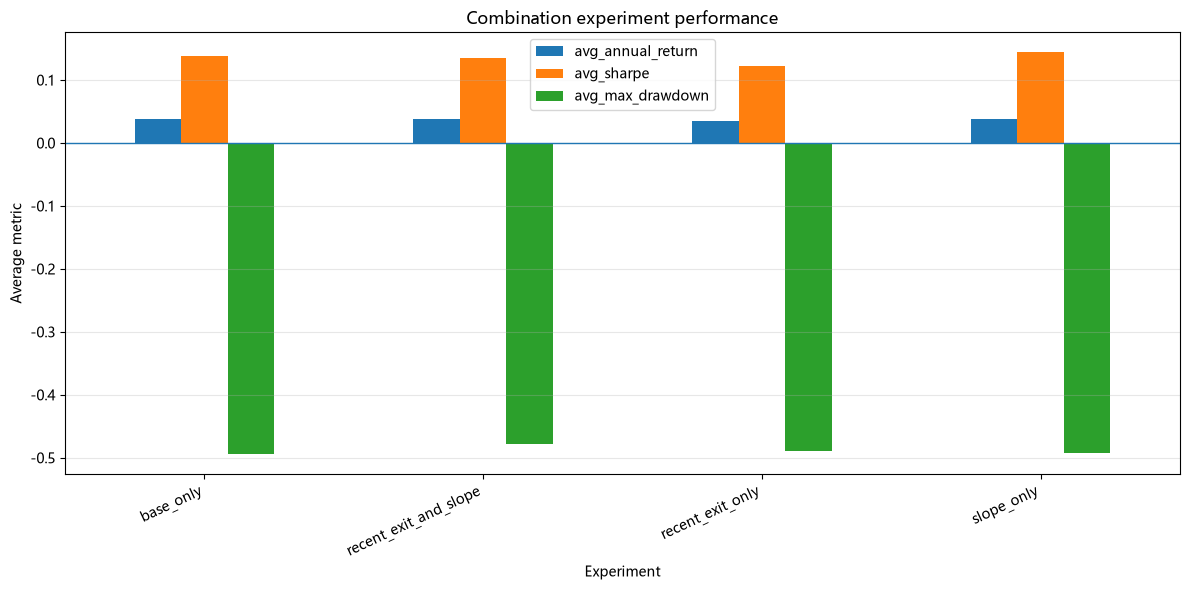

In [38]:
plot_data = (
    performance_summary
    .set_index(
        "experiment_name"
    )
    [
        [
            "avg_annual_return",
            "avg_sharpe",
            "avg_max_drawdown",
        ]
    ]
)

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.axhline(
    0.0,
    linewidth=1.0,
)

ax.set_xlabel(
    "Experiment"
)

ax.set_ylabel(
    "Average metric"
)

ax.set_title(
    "Combination experiment performance"
)

ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

plt.xticks(
    rotation=25,
    ha="right",
)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

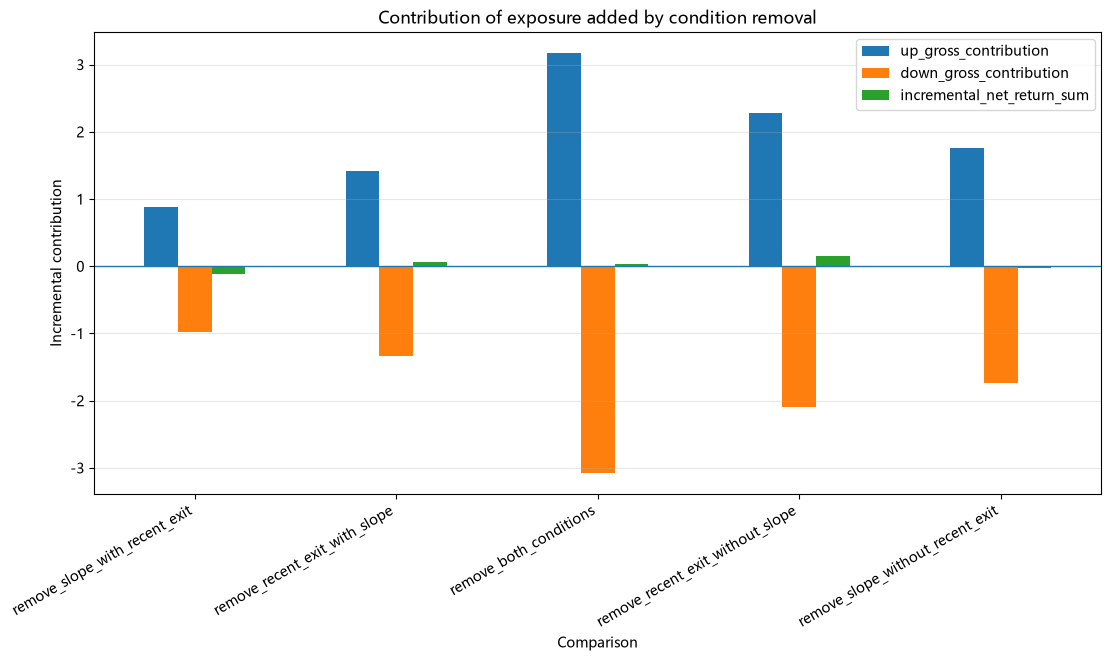

In [39]:
plot_data = (
    added_exposure_summary
    .set_index(
        "comparison_name"
    )
    [
        [
            "up_gross_contribution",
            "down_gross_contribution",
            "incremental_net_return_sum",
        ]
    ]
)

ax = plot_data.plot(
    kind="bar",
    figsize=(13, 6),
)

ax.axhline(
    0.0,
    linewidth=1.0,
)

ax.set_xlabel(
    "Comparison"
)

ax.set_ylabel(
    "Incremental contribution"
)

ax.set_title(
    "Contribution of exposure added by condition removal"
)

ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.tight_layout()
plt.show()

In [ ]:
REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

combination_summary_all.to_csv(
    REPORT_DIR
    / "combination_summary_all.csv",
    index=False,
    encoding="utf-8-sig",
)

combination_period_detail.to_csv(
    REPORT_DIR
    / "combination_period_detail.csv",
    index=False,
    encoding="utf-8-sig",
)

performance_summary.to_csv(
    REPORT_DIR
    / "performance_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

pair_summary.to_csv(
    REPORT_DIR
    / "pair_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

added_exposure_summary.to_csv(
    REPORT_DIR
    / "added_exposure_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

combination_final_summary.to_csv(
    REPORT_DIR
    / "combination_final_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

interaction_analysis.to_csv(
    REPORT_DIR
    / "interaction_analysis.csv",
    index=False,
    encoding="utf-8-sig",
)

signal_quality_summary.to_csv(
    REPORT_DIR
    / "signal_quality_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

attribution_summary.to_csv(
    REPORT_DIR
    / "attribution_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

selection_table.to_csv(
    REPORT_DIR
    / "selection_table.csv",
    index=False,
    encoding="utf-8-sig",
)

stock_comparison_detail.to_csv(
    REPORT_DIR
    / "stock_comparison_detail.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "组合实验结果已保存：",
    REPORT_DIR,
)

组合实验结果已保存： e:\quant-learning\reports\ma_graded_position_combination


## 分级仓位条件组合实验结论

### 1. 当前候选规则

* 当前基准：近期离场条件与快均线斜率条件
* 部分仓位比例：4.46%
* 平均年化收益：3.86%
* 平均夏普比率：0.1354
* 平均最大回撤：-47.87%
* benefit_cost_ratio：0.9181

### 2. 删除快均线斜率

删除快均线斜率后，平均年化收益下降 0.38 个百分点，夏普下降 0.0132，最大回撤恶化 1.09 个百分点，换手增加 12.00。新增仓位累计净贡献为 -0.1190，跨股票胜率仅为 20%。

因此，快均线斜率条件能够有效过滤无效反弹，应予以保留。

### 3. 删除近期离场

删除近期离场条件后，平均年化收益基本不变，夏普提高 0.0084，但最大回撤恶化 1.42 个百分点，换手增加 10.44。新增仓位累计净贡献为正，但跨股票胜率仅为 40%。

因此，近期离场条件并未表现出明显的收益增强价值，但在控制换手、最大回撤和长期空头环境中的风险暴露方面具有作用。考虑到策略的风险控制定位，暂时保留近期离场条件。

### 4. 同时删除两个条件

同时删除近期离场和快均线斜率条件后，平均年化收益基本不变，夏普略有提高，但最大回撤恶化 1.60 个百分点，换手增加 27.48，新增仓位股票胜率仅为 40%。

两个条件存在一定交互。完全删除两个条件不能带来稳定的综合改善，因此不采用基础规则版本。

### 5. 最简非劣选择

没有更简单的版本通过预先设定的非劣标准。当前选择“近期离场 + 快均线斜率”作为冻结候选规则，条件数量为两个。该规则没有明显依赖单只股票，但年度稳定性仍需通过新样本验证。

### 6. 当前决定

* 最终保留条件：近期离场、价格站上快均线、快均线斜率转正
* 最终删除条件：波动调整后的反弹强度条件
* 部分仓位：固定为 30%
* 近期离场窗口：固定为退出后的 1～20 个交易日
* 快均线斜率窗口：固定为 3 个交易日
* 是否冻结规则：是
* 是否进入新样本验证：是

冻结后不再使用当前开发股票池调整均线窗口、仓位比例、离场窗口、斜率窗口或触发条件。下一阶段使用全新的股票或未参与研究的未来时间区间，对原始二元 10/40、冻结分级仓位规则和买入持有进行一次性外部验证。
